# 📊 Proyecto Final — Machine Learning para Trading

## Introducción

El objetivo de este proyecto fue construir un pipeline completo de machine learning aplicado a un problema de predicción en mercados financieros, específicamente para anticipar la dirección del rendimiento diario del activo SPY. A diferencia de enfoques tradicionales centrados únicamente en métricas como accuracy o F1-score, en este trabajo se buscó evaluar el desempeño del modelo en términos de su utilidad práctica dentro de una estrategia de inversión.

Para lograrlo, se desarrolló un flujo de trabajo reproducible utilizando herramientas modernas como DVC para la gestión de datos y MLflow para el seguimiento de experimentos. A partir de datos históricos de precios, se generaron variables predictoras como retornos, rezagos y promedios móviles, junto con una variable objetivo que indica si el precio del activo aumenta o disminuye al día siguiente.

Posteriormente, se entrenaron modelos de machine learning y se evaluaron mediante métricas tradicionales. Sin embargo, el enfoque principal del proyecto consistió en trasladar estas predicciones a una simulación de trading (backtesting), donde se analizaron los rendimientos acumulados de una estrategia basada en las señales del modelo frente a una estrategia pasiva de "buy and hold".


In [12]:
import sys
from pathlib import Path
import os

PROJECT_ROOT = Path(r"C:\Users\kik3l\ml_trading_pipeline")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root added:", PROJECT_ROOT)

os.chdir(r"C:\Users\kik3l\ml_trading_pipeline")

print("Current working directory:", os.getcwd())

Project root added: C:\Users\kik3l\ml_trading_pipeline
Current working directory: C:\Users\kik3l\ml_trading_pipeline


In [13]:
print(sys.path[-1])

C:\Users\kik3l\ml_trading_pipeline


In [10]:
import pandas as pd

X = pd.read_parquet("../data/processed/features.parquet")
y = pd.read_parquet("../data/processed/target.parquet")

X.head()

,AAPL_ret,AAPL_lag1,AAPL_lag3,AAPL_ma5,NVDA_ret,NVDA_lag1,NVDA_lag3,NVDA_ma5,SPY_ret,SPY_lag1,SPY_lag3,SPY_ma5
Date,,,,,,,,,,,,
2015-01-08,0.038422,0.014022,-0.028171,23.985878,0.037618,-0.002606,-0.016890,0.470797,0.017744,0.012461,-0.018060,168.142438
2015-01-09,0.001072,0.038422,0.000094,24.104594,0.004028,0.037618,-0.030318,0.469885,-0.008014,0.017744,-0.009419,167.946985
2015-01-12,-0.024641,0.001072,0.014022,24.237485,-0.012538,0.004028,-0.002606,0.469405,-0.007833,-0.008014,0.012461,168.101028
2015-01-13,0.008879,-0.024641,0.038422,24.412901,-0.001524,-0.012538,0.037618,0.471660,-0.002813,-0.007833,0.017744,168.475345
2015-01-14,-0.003811,0.008879,0.001072,24.503709,0.004069,-0.001524,0.004028,0.474540,-0.006037,-0.002813,-0.008014,168.235175


## Ingeniería de Features

Se generaron variables a partir de los precios históricos, incluyendo:

* Retornos diarios
* Rezagos (lags)
* Promedios móviles

Estas variables permiten capturar patrones temporales y posibles señales de tendencia en el mercado.


## Modelos

Se entrenaron dos modelos principales:

* Regresión Logística (baseline)
* Random Forest (modelo no lineal)

Los resultados mostraron que ambos modelos tienen un desempeño limitado en términos de métricas tradicionales, lo cual es esperado dado el ruido inherente en los mercados financieros.


## Resultados

Los modelos obtuvieron valores cercanos a un desempeño aleatorio (ROC-AUC ≈ 0.5), lo que indica que predecir la dirección diaria del mercado es una tarea altamente compleja.

Sin embargo, estas métricas no reflejan completamente la utilidad del modelo en un contexto de trading.


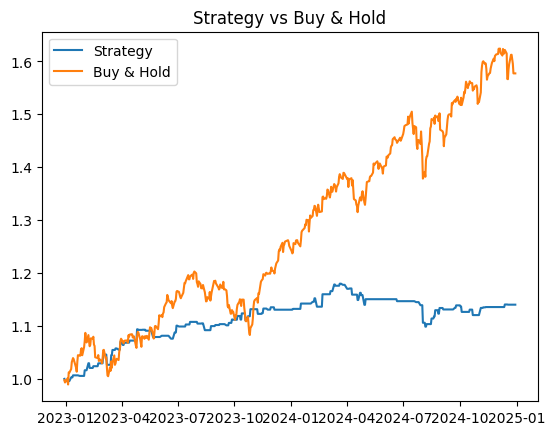


Final Strategy Return: 1.140238194799662
Final Buy & Hold Return: 1.577352496055828


In [ ]:
from src.trading_ml.evaluation.backtest import backtest

backtest()

## Backtest

Se implementó una estrategia basada en las predicciones del modelo, comparándola contra una estrategia pasiva de "buy and hold".

Resultados obtenidos:

* Strategy Return ≈ 1.14
* Buy & Hold ≈ 1.57

Aunque la estrategia no supera al benchmark, se observa una mejora significativa respecto a la versión inicial del modelo.

* Strategy Return ≈ 1.04
* Buy & Hold ≈ 1.57

Se incorporaron mejoras como:

* Uso de probabilidades en lugar de predicciones binarias
* Threshold dinámico para filtrar señales
* Reducción de sobreoperación

Esto permitió construir una estrategia más realista y robusta.


## Conclusiones

A partir de los resultados obtenidos, se puede concluir que, aunque el modelo desarrollado no logra superar a una estrategia pasiva de "buy and hold", sí permite identificar ciertos patrones que pueden ser aprovechados bajo un enfoque más selectivo de operación.

Un aprendizaje clave es que no basta con construir un modelo predictivo, sino que es fundamental definir cómo se utilizan dichas predicciones en la toma de decisiones. En este caso, el uso de probabilidades y filtros permitió mejorar el desempeño de la estrategia.

Finalmente, este proyecto demuestra la importancia de combinar machine learning con buenas prácticas de ingeniería, como reproducibilidad, versionamiento de datos y seguimiento de experimentos.
